Pricing supplement: https://www.sec.gov/Archives/edgar/data/831001/000095010324017597/dp221959_424b2-us2428144d.htm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 1. Dates and Features

In [ ]:
pricing_date = date(2024, 12, 9)
issue_date = date(2024, 12, 12)
final_valuation_date = date(2026, 1, 9)
maturity_date = date(2026, 1, 14)

autocall_dates = valuation_dates = np.array([
    date(2025, 6, 9), date(2025, 7, 9), date(2025, 8, 11),
    date(2025, 9, 9), date(2025, 10, 9), date(2025, 11, 10),
    date(2025, 12, 9)])
autocall_dates = np.array([diff_date.days for diff_date in autocall_dates - pricing_date])

observation_dates = np.array([
    date(2025, 1, 9), date(2025, 2, 10), date(2025, 3, 10),
    date(2025, 4, 9), date(2025, 5, 9), date(2025, 6, 9),
    date(2025, 7, 9), date(2025, 8, 11), date(2025, 9, 9),
    date(2025, 10, 9), date(2025, 11, 10), date(2025, 12, 9),
    date(2026, 1, 9)])
observation_dates = np.array([diff_date.days for diff_date in observation_dates - pricing_date])
ex_autocall_dates = np.setdiff1d(observation_dates, autocall_dates)

coupon_dates = np.array([
    date(2025, 1, 13), date(2025, 2, 13), date(2025, 3, 13),
    date(2025, 4, 14), date(2025, 5, 12), date(2025, 6, 12),
    date(2025, 7, 14), date(2025, 8, 14), date(2025, 9, 12),
    date(2025, 10, 13), date(2025, 11, 13), date(2025, 12, 12),
    date(2026, 1, 14)])
coupon_dates = np.array([diff_date.days for diff_date in coupon_dates - pricing_date])
coupon_dates_ac = coupon_dates[-len(autocall_dates):]
coupon_dates_ex = np.setdiff1d(coupon_dates, coupon_dates_ac)

S0 = 246.75
coupon_barrier = 192.465
knock_in = 192.465
equity_ratio = 4.05268
coupon_rate = 0.0075  # Monthly rate
principal = 1000
estimated_value = 978.5  # Estimated value on the pricing date from description

# 2. Parameters of Stock

In [ ]:
# Interest rate and discount rate between pricing date and maturity date
discount = interp1d([datetime(2025, 12, 9).timestamp(), datetime(2026, 6, 9).timestamp()],
            [0.959527, 0.941839], kind='linear')(datetime(2026, 1, 14).timestamp())
r = -np.log(discount) / ((maturity_date - pricing_date).days / 365)

# dates of implied volatility and dates we need
quote_dates = np.array([
    datetime(2025, 1, 9).timestamp(), datetime(2025, 2, 9).timestamp(), datetime(2025, 3, 9).timestamp(),
    datetime(2025, 4, 9).timestamp(), datetime(2025, 5, 9).timestamp(), datetime(2025, 6, 9).timestamp(),
    datetime(2025, 7, 9).timestamp(), datetime(2025, 8, 9).timestamp(), datetime(2025, 9, 9).timestamp(),
    datetime(2025, 10, 9).timestamp(), datetime(2025, 11, 9).timestamp(), datetime(2025, 12, 9).timestamp(),
    datetime(2026, 1, 9).timestamp(), datetime(2026, 2, 9).timestamp()])

target_dates = np.array([
    datetime(2025, 1, 13).timestamp(), datetime(2025, 2, 13).timestamp(), datetime(2025, 3, 13).timestamp(),
    datetime(2025, 4, 14).timestamp(), datetime(2025, 5, 12).timestamp(), datetime(2025, 6, 12).timestamp(),
    datetime(2025, 7, 14).timestamp(), datetime(2025, 8, 14).timestamp(), datetime(2025, 9, 12).timestamp(),
    datetime(2025, 10, 13).timestamp(), datetime(2025, 11, 13).timestamp(), datetime(2025, 12, 12).timestamp(),
    datetime(2026, 1, 14).timestamp()])

# volatility vector corresponding to coupon barrier
sigma_vec_barrier = interp1d(quote_dates, [0.37422, 0.32481, 0.30858, 0.28883, 0.28119, 0.28088, 0.27784, 0.27784, 0.27741, 0.27707, 0.27712, 0.27640, 0.27368, 0.27167], kind='linear')
sigma_barrier = sigma_vec_barrier(target_dates)[-1]
sigma_avg_barrier = sigma_vec_barrier(target_dates).mean()

# volatility vector corresponding to at-the-money price
sigma_vec_atm = interp1d(quote_dates, [0.17039, 0.20182, 0.21347, 0.21379, 0.21867, 0.22456, 0.22489, 0.23024, 0.23136, 0.23218, 0.23396, 0.23543, 0.23596, 0.23655], kind='linear')
sigma_atm = sigma_vec_atm(target_dates)[-1]
sigma_avg_atm = sigma_vec_atm(target_dates).mean()

# dividend yield
delta = 0.00403

In [ ]:
sigma_avg_barrier, sigma_barrier, sigma_atm, sigma_avg_atm

(np.float64(0.2909415308992083),
 np.float64(0.2733558064516129),
 np.float64(0.23605516129032258),
 np.float64(0.2211996208200402))

# 3. Finite Difference Pricer

## 3.1. Explicit

In [ ]:
contingent_coupon = lambda S: np.where(S>=coupon_barrier, principal * coupon_rate, 0)

In [ ]:
def ExplicitFD_Trigger(S0, r, q, sigma, T, SU, ni, jMax):
  # Generate grid
  iMax = ni * T
  dt = 1 / 365 / ni
  dS = SU / jMax
  jValues = np.arange(0, jMax)
  jb = int(0.78 * S0 / dS)
  j0 = int(S0 / dS)
  SValues = np.linspace(0, SU, jMax+1)
  V = np.zeros((iMax+1, jMax+1))

  coupon_dates_ni = coupon_dates * ni
  coupon_dates_ex_ni = coupon_dates_ex * ni
  coupon_dates_ac_ni = coupon_dates_ac * ni

  # Terminal condition
  V[-1] = np.where(SValues>=S0, principal, equity_ratio*SValues) + contingent_coupon(SValues)
  # Lower boundary condition
  V[:, 0] = 0
  # Upper boundary condition
  coupon = contingent_coupon(SU)
  for i in range(iMax):
    Di = np.ceil(float(i)/ni)
    if Di < autocall_dates[0]:
      Di = coupon_dates_ex_ni - i
      Di = Di[Di>=0]
      V[i, -1] = coupon * np.exp(-r*(Di*dt)).sum() + (principal + coupon) * np.exp(-r*(coupon_dates_ac[0]*ni-i)*dt)
    else:
      Di = coupon_dates_ac_ni - i
      Di = Di[Di>=0][0]
      V[i, -1] = (principal + coupon) * np.exp(-r*Di*dt)

  # Finite difference
  for i in range(iMax-1, -1, -1):
    A = (0.5 * sigma**2 * jValues**2 + (r-q) * jValues / 2) * dt
    B = 1 - r * dt - sigma**2 * jValues**2 * dt
    C = (0.5 * sigma**2 * jValues**2 - (r-q) * jValues / 2) * dt

    for j in range(1, jMax-1):
      if i in coupon_dates_ac_ni and j >= j0:
        V[i, j] = principal + coupon
      else:
        V[i, j] = A[j]*V[i+1, j+1] + B[j]*V[i+1, j] + C[j]*V[i+1, j-1]
        if i in coupon_dates_ni:
          V[i, j] += contingent_coupon(SValues[j])

  return  V[:,jb], np.interp(S0, SValues, V[0])

In [ ]:
def ExplicitFD_noTrigger(S0, r, q, sigma, T, SL, SU, ni, jMax, VTjb):
  # Generate grid
  iMax = ni * T
  dt = 1 / 365 / ni
  dS = (SU - SL) / jMax
  jValues = np.arange(0, jMax)
  j0 = int((S0 - SL) / dS)
  SValues = np.linspace(SL, SU, jMax+1)
  V = np.zeros((iMax+1, jMax+1))

  coupon_dates_ni = coupon_dates * ni
  coupon_dates_ex_ni = coupon_dates_ex * ni
  coupon_dates_ac_ni = coupon_dates_ac * ni

  # Terminal condition
  V[-1] = principal + contingent_coupon(SValues)
  # Lower boundary condition
  V[:, 0] = VTjb
  # Upper boundary condition
  coupon = contingent_coupon(SU)
  for i in range(iMax):
    Di = np.ceil(float(i)/ni)
    if Di < autocall_dates[0]:
      Di = coupon_dates_ex_ni - i
      Di = Di[Di>=0]
      V[i, -1] = coupon * np.exp(-r*(Di*dt)).sum() + (principal + coupon) * np.exp(-r*(coupon_dates_ac[0]*ni-i)*dt)
    else:
      Di = coupon_dates_ac_ni - i
      Di = Di[Di>=0][0]
      V[i, -1] = (principal + coupon) * np.exp(-r*Di*dt)

  # Finite difference
  for i in range(iMax-1, -1, -1):
    A = (0.5 * sigma**2 * (SL/dS + jValues)**2 + (r-q) * (SL/dS + jValues) / 2) * dt
    B = 1 - r * dt - sigma**2 * (SL/dS + jValues)**2 * dt
    C = (0.5 * sigma**2 * (SL/dS + jValues)**2 - (r-q) * (SL/dS + jValues) / 2) * dt

    for j in range(1, jMax-1):
      if i in coupon_dates_ac_ni and j >= j0:
        V[i, j] = principal + coupon
      else:
        V[i, j] = A[j]*V[i+1, j+1] + B[j]*V[i+1, j] + C[j]*V[i+1, j-1]
        if i in coupon_dates_ni:
          V[i, j] += contingent_coupon(SValues[j])

  return  np.interp(S0, SValues, V[0])

In [ ]:
VTjb, PT = ExplicitFD_Trigger(S0, r, delta, sigma_atm, T=coupon_dates[-1], SU=2.5*S0, ni=100, jMax=250)
P = ExplicitFD_noTrigger(S0, r, delta, sigma_atm, T=coupon_dates[-1], SL=0.78*S0, SU=2.50*S0, ni=100, jMax=172, VTjb=VTjb)
PT, P

(np.float64(968.4094879178215), np.float64(973.9248627118736))

## 3.2. Crank-Nicolson

In [ ]:
def CNFD_Trigger(S0, r, q, sigma, T, SU, ni, jMax):
  # Generate grid
  iMax = ni * T
  dt = 1 / 365 / ni
  dS = SU / jMax
  jValues =  np.arange(1, jMax)# np.arange(jMax+1)
  jb = int(0.78 * S0 / dS)
  j0 = int(S0 / dS)
  SValues = np.linspace(0, SU, jMax+1)
  V = np.zeros((iMax+1, jMax+1))

  coupon_dates_ni = coupon_dates * ni
  coupon_dates_ex_ni = coupon_dates_ex * ni
  coupon_dates_ac_ni = coupon_dates_ac * ni

  # Terminal condition
  V[-1] = np.where(SValues>=S0, principal, equity_ratio*SValues) + contingent_coupon(SValues)
  # Lower boundary condition
  V[:, 0] = 0
  # Upper boundary condition and autocall condition
  coupon = contingent_coupon(SU)
  for i in range(iMax):
    Di = np.ceil(float(i)/ni)
    if Di < autocall_dates[0]:
      Di = coupon_dates_ex_ni - i
      Di = Di[Di>=0]
      V[i, -1] = coupon * np.exp(-r*(Di*dt)).sum() + (principal + coupon) * np.exp(-r*(coupon_dates_ac[0]*ni-i)*dt)
    else:
      Di = coupon_dates_ac_ni - i
      Di = Di[Di>=0][0]
      V[i, -1] = (principal + coupon) * np.exp(-r*Di*dt)

  # Finite difference
  for i in range(iMax-1, -1, -1):
    size = jMax - 1
    a = 0.25 * dt * (sigma**2 * jValues**2 - (r - q) * jValues)
    b = -0.5 * dt * (sigma**2 * jValues**2 + r)
    c = 0.25 * dt * (sigma**2 * jValues**2 + (r - q) * jValues)

    # M2 * Vi,j = M1 * Vi+1,j + b
    M1 = diags(diagonals=[a[1:], 1 + b, c[:-1]], offsets=[-1, 0, 1], shape=(size, size), format='lil')
    M2 = diags(diagonals=[-a[1:], 1 - b, -c[:-1]], offsets=[-1, 0, 1], shape=(size, size), format='lil')

    if i in coupon_dates_ac_ni:
      M1 = M1[:j0-1,:j0-1].tocsc()
      M2 = M2[:j0-1,:j0-1].tocsc()
      vb = np.zeros(j0-1)
      vb[0] = a[0] * (V[i, 0] + V[i+1, 0])
      vb[-1] = c[j0-2] * (V[i, j0] + V[i+1, j0])
      V[i, 1:j0] = spsolve(M2, M1.dot(V[i+1, 1:j0])+vb)+ contingent_coupon(SValues[1:j0])
      V[i, j0:] = principal + coupon
    else:
      M1 = M1.tocsc()
      M2 = M2.tocsc()
      vb = np.zeros(size)
      vb[0] = a[0] * (V[i, 0] + V[i+1, 0])
      vb[-1] = c[-1] * (V[i, -1] + V[i+1, -1])
      V[i, 1:-1] = spsolve(M2, M1.dot(V[i+1, 1:-1])+vb)
      if i in coupon_dates_ni:
        V[i, 1:-1] += contingent_coupon(SValues[1:-1])

  return  V[:,jb], np.interp(S0, SValues, V[0])

In [ ]:
def CNFD_noTrigger(S0, r, q, sigma, T, SL, SU, ni, jMax, VTjb):
  # Generate grid
  iMax = ni * T
  dt = 1 / 365 / ni
  dS = (SU - SL) / jMax
  jValues = np.arange(1, jMax)
  j0 = int((S0 - SL) / dS)
  SValues = np.linspace(SL, SU, jMax+1)
  V = np.zeros((iMax+1, jMax+1))

  coupon_dates_ni = coupon_dates * ni
  coupon_dates_ex_ni = coupon_dates_ex * ni
  coupon_dates_ac_ni = coupon_dates_ac * ni

  # Terminal condition
  V[-1] = principal + contingent_coupon(SValues)
  # Lower boundary condition
  V[:, 0] = VTjb
  # Upper boundary condition
  coupon = contingent_coupon(SU)
  for i in range(iMax):
    Di = np.ceil(float(i)/ni)
    if Di < autocall_dates[0]:
      Di = coupon_dates_ex_ni - i
      Di = Di[Di>=0]
      V[i, -1] = coupon * np.exp(-r*(Di*dt)).sum() + (principal + coupon) * np.exp(-r*(coupon_dates_ac[0]*ni-i)*dt)
    else:
      Di = coupon_dates_ac_ni - i
      Di = Di[Di>=0][0]
      V[i, -1] = (principal + coupon) * np.exp(-r*Di*dt)

  # Finite difference
  coupon_dates_ni = coupon_dates * ni
  for i in range(iMax-1, -1, -1):
    size = jMax - 1
    a = 0.25 * dt * ((SL/dS+jValues)**2 * sigma**2 - (r - q) * (SL/dS+jValues))
    b = -0.5 * dt * ((SL/dS+jValues)**2 * sigma**2 + r)
    c = 0.25 * dt * ((SL/dS+jValues)**2 * sigma**2 + (r - q) * (SL/dS+jValues))

    # M2 * Vi,j = M1 * Vi+1,j + b
    M1 = diags(diagonals=[a[1:], 1 + b, c[:-1]], offsets=[-1, 0, 1], shape=(size, size), format='lil')
    M2 = diags(diagonals=[-a[1:], 1 - b, -c[:-1]], offsets=[-1, 0, 1], shape=(size, size), format='lil')

    if i in coupon_dates_ac_ni:#>= (autocall_dates[0]-1)*ni+1:
      M1 = M1[:j0-1,:j0-1].tocsc()
      M2 = M2[:j0-1,:j0-1].tocsc()
      vb = np.zeros(j0-1)
      vb[0] = a[0] * (V[i, 0] + V[i+1, 0])
      vb[-1] = c[j0-2] * (V[i, j0] + V[i+1, j0])
      V[i, 1:j0] = spsolve(M2, M1.dot(V[i+1, 1:j0])+vb) + contingent_coupon(SValues[1:j0])
      V[i, j0:] = principal + coupon
    else:
      M1 = M1.tocsc()
      M2 = M2.tocsc()
      vb = np.zeros(size)
      vb[0] = a[0] * (V[i, 0] + V[i+1, 0])
      vb[-1] = c[-1] * (V[i, -1] + V[i+1, -1])
      V[i, 1:-1] = spsolve(M2, M1.dot(V[i+1, 1:-1])+vb)
      if i in coupon_dates_ni:
        V[i, 1:-1] += contingent_coupon(SValues[1:-1])

  return  np.interp(S0, SValues, V[0])

In [ ]:
VTjbCN, PTCN = CNFD_Trigger(S0, r, delta, sigma_atm, T=coupon_dates[-1], SU=2.5*S0, ni=100, jMax=250)
PCN = CNFD_noTrigger(S0, r, delta, sigma_atm, T=coupon_dates[-1], SL=0.78*S0, SU=2.5*S0, ni=100, jMax=172, VTjb=VTjbCN)
PTCN, PCN

(np.float64(968.2156915963022), np.float64(973.7288906104651))

# 4. Sensitive Analysis

## 4.1. Volatility

In [ ]:
vol_list = [sigma_avg_atm, sigma_atm, sigma_barrier, sigma_avg_barrier]
explicit_price_vol = []
cn_price_vol = []

for sigma in vol_list:
  VTjb, PT = ExplicitFD_Trigger(S0, r, delta, sigma, T=coupon_dates[-1], SU=2.5*S0, ni=50, jMax=250)
  P = ExplicitFD_noTrigger(S0, r, delta, sigma, T=coupon_dates[-1], SL=0.78*S0, SU=2.50*S0, ni=50, jMax=172, VTjb=VTjb)
  explicit_price_vol.append((PT, P))

  VTjbCN, PTCN = CNFD_Trigger(S0, r, delta, sigma, T=coupon_dates[-1], SU=2.5*S0, ni=50, jMax=250)
  PCN = CNFD_noTrigger(S0, r, delta, sigma, T=coupon_dates[-1], SL=0.78*S0, SU=2.5*S0, ni=50, jMax=172, VTjb=VTjbCN)
  cn_price_vol.append((PTCN, PCN))

In [ ]:
explicit_price_vol = np.array(explicit_price_vol)
cn_price_vol = np.array(cn_price_vol)
PT = explicit_price_vol[:,0]
P = explicit_price_vol[:,1]
PTCN = cn_price_vol[:,0]
PCN = cn_price_vol[:,1]
PT, P, PTCN, PCN

(array([974.21763805, 968.40924001, 953.71376041, 946.75923941]),
 array([981.25414999, 973.92401616, 956.5463323 , 948.78645798]),
 array([973.85303532, 968.02247783, 953.28545098, 946.33492941]),
 array([980.88509474, 973.53292377, 956.11434887, 948.35888491]))

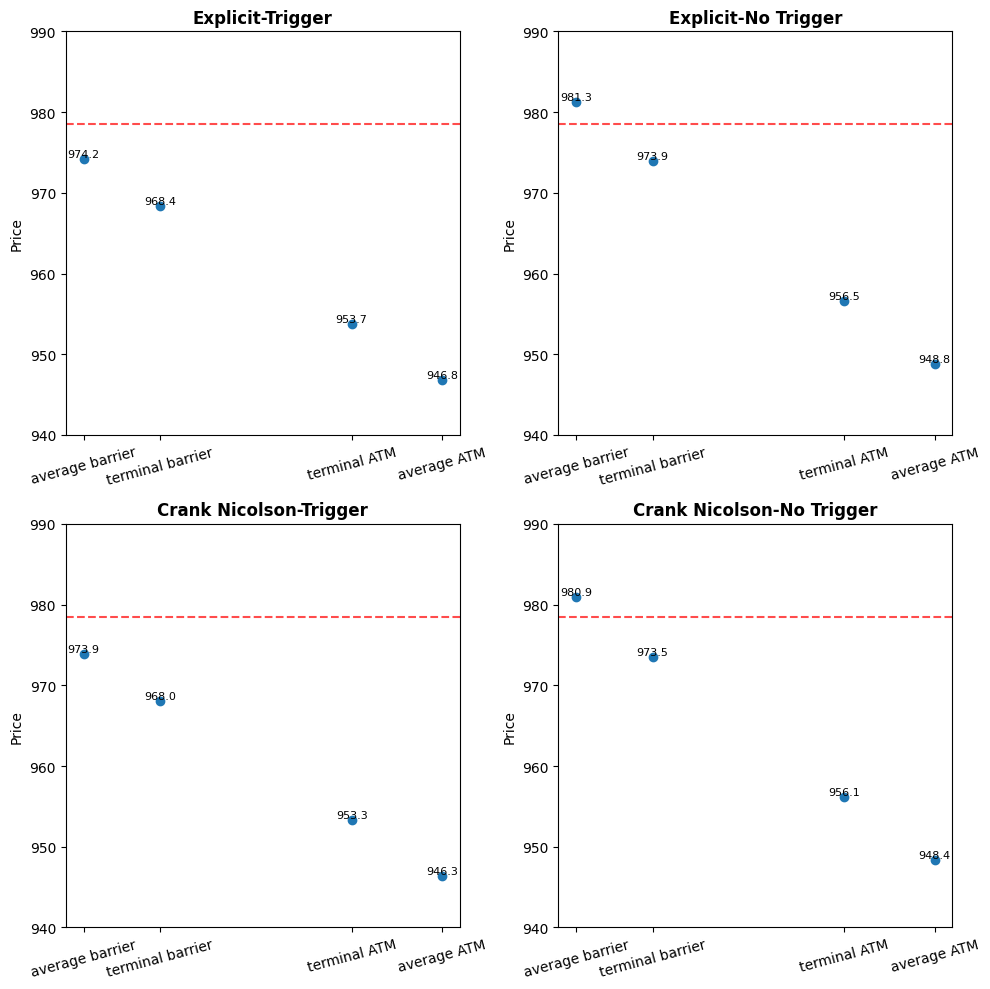

In [ ]:
plt.figure(figsize=(10, 10))
# plt.suptitle('Sensitivity to Volatility', fontsize=16, fontweight='bold', y=0.95)

plt.subplot(2, 2, 1)
plt.scatter(vol_list, PT)
plt.axhline(y=estimated_value, color='r', linestyle='--', alpha=0.7, label='Reference Line (950)')
for x, y in zip(vol_list, PT):
  plt.text(x, y, f"{y:.1f}", ha='center', va='bottom', fontsize=8)
plt.xticks(vol_list, ["average barrier", "terminal barrier", "terminal ATM", "average ATM"], rotation=15)
plt.ylim(940, 990)
#plt.xlabel('Volatility Type')
plt.ylabel('Price')
plt.title('Explicit-Trigger', fontweight='bold')
plt.tight_layout()

plt.subplot(2, 2, 2)
plt.scatter(vol_list, P)
plt.axhline(y=estimated_value, color='r', linestyle='--', alpha=0.7, label='Reference Line (950)')
for x, y in zip(vol_list, P):
  plt.text(x, y, f"{y:.1f}", ha='center', va='bottom', fontsize=8)
plt.xticks(vol_list, ["average barrier", "terminal barrier", "terminal ATM", "average ATM"], rotation=15)
plt.ylim(940, 990)
#plt.xlabel('Volatility Type')
plt.ylabel('Price')
plt.title('Explicit-No Trigger', fontweight='bold')
plt.tight_layout()

plt.subplot(2, 2, 3)
plt.scatter(vol_list, PTCN)
plt.axhline(y=estimated_value, color='r', linestyle='--', alpha=0.7, label='Reference Line (950)')
for x, y in zip(vol_list, PTCN):
  plt.text(x, y, f"{y:.1f}", ha='center', va='bottom', fontsize=8)
plt.xticks(vol_list, ["average barrier", "terminal barrier", "terminal ATM", "average ATM"], rotation=15)
plt.ylim(940, 990)
#plt.xlabel('Volatility Type')
plt.ylabel('Price')
plt.title('Crank Nicolson-Trigger', fontweight='bold')
plt.tight_layout()

plt.subplot(2, 2, 4)
plt.scatter(vol_list, PCN)
plt.axhline(y=estimated_value, color='r', linestyle='--', alpha=0.7, label='Reference Line (950)')
for x, y in zip(vol_list, PCN):
  plt.text(x, y, f"{y:.1f}", ha='center', va='bottom', fontsize=8)
plt.xticks(vol_list, ["average barrier", "terminal barrier", "terminal ATM", "average ATM"], rotation=15)
plt.ylim(940, 990)
#plt.xlabel('Volatility Type')
plt.ylabel('Price')
plt.title('Crank Nicolson-No Trigger', fontweight='bold')
plt.tight_layout()

plt.show()

## 4.2. Grid size

In [ ]:
def check_stability(sigma, dt, jMax):
    if dt <= 1.0 / (sigma**2 * jMax**2):
        return True
    else:
        return False

# --- Sensitivity test for grid size ---
def grid_sensitivity(S0, r, q, sigma, T, SL, SU, ni_list, jMax_list):
    results = []
    dt = 1/365/ni_list[0]
    for ni in ni_list:
        dt = 1 / (365 * ni)
        for jMax in jMax_list:
            if not check_stability(sigma, dt, jMax):
                print(f"Unstable grid skipped: ni={ni}, jMax={jMax}, dt={dt:.2e}")
                continue
            try:
                VTjb, _ = ExplicitFD_Trigger(S0, r, q, sigma, T, SU, ni, jMax)
                price = ExplicitFD_noTrigger(S0, r, q, sigma, T, SL, SU, ni, jMax, VTjb)
                results.append((ni, jMax, price))
            except Exception as e:
                print(f"Failed for ni={ni}, jMax={jMax}: {e}")
    return results

ni_list = [50, 100, 200, 300, 500]
jMax_list = [100, 172, 250, 400, 500, 750, 1000]
sensitivity_results = grid_sensitivity(S0, r, delta, sigma_atm, T=coupon_dates[-1],
                                       SL=0.78*S0, SU=2.5*S0, ni_list=ni_list,
                                       jMax_list=jMax_list)

prices_matrix = np.zeros((len(ni_list), len(jMax_list)))
for (ni, jMax, price) in sensitivity_results:
    i = ni_list.index(ni)
    j = jMax_list.index(jMax)
    prices_matrix[i, j] = price

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

X, Y = np.meshgrid(jMax_list, ni_list)

Z = np.where((prices_matrix == 0) | np.isnan(prices_matrix), np.nan, prices_matrix)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="k", linewidth=0.5)

ax.set_xlabel("jMax (space steps)")
zmin = np.nanmin(Z) * 0.97
zmax = np.nanmax(Z) * 1.01
ax.set_zlim(zmin, zmax)
ax.set_ylabel("ni (time steps/day)")
ax.set_zlabel("Price")
ax.set_title("3D Sensitivity of ExplicitFD_noTrigger to Grid Size")
fig.colorbar(surf, shrink=0.5, aspect=8)
plt.show()

In [ ]:
SU_list = [2.0, 2.5, 3.0, 4.0, 5.0, 7.5, 10.0]
prices_SU = []

VTjb, _ = ExplicitFD_Trigger(S0, r, delta, sigma_atm, T=coupon_dates[-1], SU=2.5*S0, ni=100, jMax=250)
for SU in SU_list:
    price = ExplicitFD_noTrigger(S0, r, delta, sigma_atm, T=coupon_dates[-1],
                                 SL=0.78*S0, SU=SU*S0, ni=100, jMax=172, VTjb=VTjb)
    prices_SU.append(price)

plt.figure(figsize=(8,6))
plt.plot(SU_list, prices_SU, marker="o", label="Price vs SU")
plt.axhline(978.5, color="r", linestyle="--", label="Market Price")
plt.xlabel("Upper Boundary $S_U$")
plt.ylabel("Price")
plt.title("Sensitivity of ExplicitFD_noTrigger to Upper Boundary")
plt.legend()
plt.ylim(min(prices_SU) * 0.995, max(prices_SU) * 1.005)
plt.show()